In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression
import seaborn as sns

In [ ]:
data=pd.read_csv("/content/housing.csv")
df=pd.DataFrame(data)
print(df.shape)
print(df.head())
print(df.isnull().sum())
print(df.columns.tolist())


(20640, 10)
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
longitude               0
latitude                0
housing_med

In [ ]:
print(df.dtypes)

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object


In [ ]:
print(df['median_house_value'].describe())
print(df['ocean_proximity'].value_counts())
print(df.corr(numeric_only=True)['median_house_value'].sort_values(ascending=True))

count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: median_house_value, dtype: float64
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64
latitude             -0.144160
longitude            -0.045967
population           -0.024650
total_bedrooms        0.049686
households            0.065843
housing_median_age    0.105623
total_rooms           0.134153
median_income         0.688075
median_house_value    1.000000
Name: median_house_value, dtype: float64


In [ ]:
df=df[df['ocean_proximity'] != 'ISLAND']
print(df.shape)
print(df['ocean_proximity'].value_counts())

(20635, 10)
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
Name: count, dtype: int64


In [ ]:
df['rooms_per_household']=(df['total_rooms']/df['households'])
df['bedrooms_per_room']=(df['total_bedrooms']/df['total_rooms'])
df['population_per_household']=(df['population']/df['households'])
print(df[['rooms_per_household','bedrooms_per_room','population_per_household']].describe().round(2))
new_features=['rooms_per_household','bedrooms_per_room','population_per_household']
print(df[new_features+['median_house_value']].corr()['median_house_value'])

       rooms_per_household  bedrooms_per_room  population_per_household
count             20635.00           20428.00                  20635.00
mean                  5.43               0.21                      3.07
std                   2.47               0.06                     10.39
min                   0.85               0.10                      0.69
25%                   4.44               0.18                      2.43
50%                   5.23               0.20                      2.82
75%                   6.05               0.24                      3.28
max                 141.91               1.00                   1243.33
rooms_per_household         0.151968
bedrooms_per_room          -0.256397
population_per_household   -0.023719
median_house_value          1.000000
Name: median_house_value, dtype: float64


In [ ]:
for col in ['rooms_per_household','bedrooms_per_room','population_per_household']:
  per_quantile=df[col].quantile(0.99)
  df[col].clip(upper=per_quantile)
  print(f"{col} capped at {per_quantile}")
print(df[['rooms_per_household','bedrooms_per_room','population_per_household']].max().round(2))

rooms_per_household capped at 10.35736842105263
bedrooms_per_room capped at 0.4066489104116221
population_per_household capped at 5.39496433604336
rooms_per_household          141.91
bedrooms_per_room              1.00
population_per_household    1243.33
dtype: float64


In [ ]:
print(df['rooms_per_household'].max())

141.9090909090909


In [ ]:
# round() on float works differently
# Use this instead:

print("Max values AFTER capping:")
print("rooms_per_household:",
       round(df['rooms_per_household'].max(), 2))
print("bedrooms_per_room:",
       round(df['bedrooms_per_room'].max(), 2))
print("population_per_household:",
       round(df['population_per_household'].max(), 2))

Max values AFTER capping:
rooms_per_household: 141.91
bedrooms_per_room: 1.0
population_per_household: 1243.33


In [ ]:
# Step 1 — Check current max BEFORE capping
print("BEFORE capping:")
print("rooms_per_household max:",
       round(df['rooms_per_household'].max(), 2))

# Step 2 — Cap each column
df['rooms_per_household'] = df['rooms_per_household'].clip(
    upper=df['rooms_per_household'].quantile(0.99))

df['bedrooms_per_room'] = df['bedrooms_per_room'].clip(
    upper=df['bedrooms_per_room'].quantile(0.99))

df['population_per_household'] = df['population_per_household'].clip(
    upper=df['population_per_household'].quantile(0.99))

# Step 3 — Check max AFTER capping
print("\nAFTER capping:")
print("rooms_per_household max:",
       round(df['rooms_per_household'].max(), 2))
print("bedrooms_per_room max:",
       round(df['bedrooms_per_room'].max(), 2))
print("population_per_household max:",
       round(df['population_per_household'].max(), 2))

BEFORE capping:
rooms_per_household max: 141.91

AFTER capping:
rooms_per_household max: 10.36
bedrooms_per_room max: 0.41
population_per_household max: 5.39


In [ ]:
x=df.drop('median_house_value',axis=1)
y=df['median_house_value']
print(x.shape)
print(y.shape)
print(x.columns.tolist())
print(y.head())

(20635, 12)
(20635,)
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']
0    452600.0
1    358500.0
2    352100.0
3    341300.0
4    342200.0
Name: median_house_value, dtype: float64


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)
print(round(y_train.mean(),2))
print(round(y_test.mean(),2))
# Use only 5000 rows for faster training
X_train_small = x_train.sample(5000, random_state=42)
y_train_small = y_train[X_train_small.index]

(16508, 12)
(4127, 12)
206996.86
206081.36


In [ ]:
numeric_cols=['longitude', 'latitude',
              'housing_median_age', 'total_rooms',
              'total_bedrooms', 'population', 'households',
              'median_income', 'rooms_per_household',
              'bedrooms_per_room', 'population_per_household']
cat_cols=['ocean_proximity']
print(" numeric columns: ",len(numeric_cols))
print(" categorical columns: ",len(cat_cols))

 numeric columns:  11
 categorical columns:  1


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import KNNImputer,SimpleImputer
from sklearn.compose import ColumnTransformer
numerical_pipeline=Pipeline([('imputer',KNNImputer(n_neighbors=5)),('scaler',StandardScaler())])
categorical_pipeline=Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('encoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False))])
preprocessor=ColumnTransformer([('num',numerical_pipeline,numeric_cols),('cat',categorical_pipeline,cat_cols)])

In [ ]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score,KFold
models={
    'linear regression':LinearRegression(),
    'ridge':Ridge(alpha=1.0),
    'lasso':Lasso(alpha=1.0),
    'random fores':RandomForestClassifier(n_estimators=50,random_state=42,n_jobs=-1),
    'xgboost':XGBRegressor(n_estimators=50,random_state=42,verbosity=0)
}
cv=KFold(n_splits=3,shuffle=True,random_state=42)
print('total models: ',len(models))

total models:  5


In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
result={}
for name,model in models.items():
  full_pipeline=Pipeline([('preprocessor',preprocessor),('model',model)])
  MSE=cross_val_score(full_pipeline,X_train_small,y_train_small,cv=cv,scoring='neg_mean_squared_error')
  MAE=cross_val_score(full_pipeline,X_train_small,y_train_small,cv=cv,scoring='neg_mean_absolute_error')
  r2=cross_val_score(full_pipeline,X_train_small,y_train_small,cv=cv,scoring='r2')
  RMSE=np.sqrt(-MSE)
  result[name]={
      'MSE':np.mean(MSE).round(2),
      'MAE':np.mean(MAE).round(2),
      'r2':np.mean(r2).round(2)
  }
  print(f"{name} done")
  print(f"mean squared error: {np.mean(MSE).round(2)}")
  print(f"r2 score: {np.mean(r2).round(2)}")
  print(f"mean absolute error: {np.mean(MAE).round(2)}")
  print(f"root mean squared error: {np.mean(RMSE).round(2)}")

linear regression done
mean squared error: -4283216003.32
r2 score: 0.68
mean absolute error: -48060.01
root mean squared error: 65442.42
ridge done
mean squared error: -4283083005.71
r2 score: 0.68
mean absolute error: -48055.39
root mean squared error: 65441.37
lasso done
mean squared error: -4283224306.09
r2 score: 0.68
mean absolute error: -48059.85
root mean squared error: 65442.49
random fores done
mean squared error: -6367174276.61
r2 score: 0.52
mean absolute error: -52222.05
root mean squared error: 79764.37
xgboost done
mean squared error: -2713657106.87
r2 score: 0.79
mean absolute error: -35235.8
root mean squared error: 52067.49


In [ ]:
from sklearn.model_selection import GridSearchCV

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(random_state=42,
                           verbosity=0))
])

param_grid = {
    'model__n_estimators'  : [100, 200],
    'model__max_depth'     : [3, 5, 7],
    'model__learning_rate' : [0.01, 0.1]
}

grid_search = GridSearchCV(
    xgb_pipeline,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train)

print("\nBest Parameters:")
print(grid_search.best_params_)
print(f"\nBest R²: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 200}

Best R²: 0.8382


FINAL MODEL EVALUATION ON TEST SET
R²   → 0.8433
RMSE → $45,481.76
MAE  → $29,198.56

CV R²   → 0.8382
Test R² → 0.8433


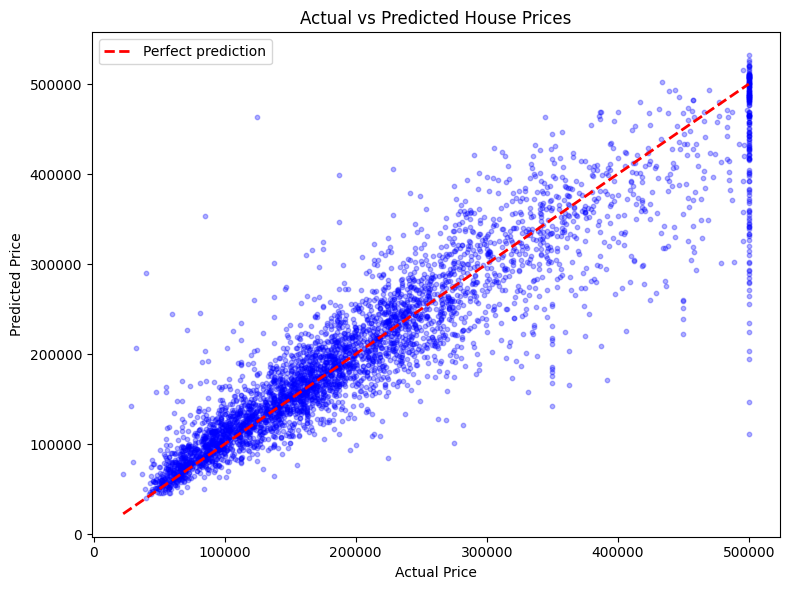

In [ ]:
from sklearn.metrics import (mean_squared_error,
                             mean_absolute_error,
                             r2_score)

# Best model
best_model = grid_search.best_estimator_

# Predictions on test set
y_pred = best_model.predict(x_test)

print("=" * 45)
print("FINAL MODEL EVALUATION ON TEST SET")
print("=" * 45)

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

print(f"R²   → {r2:.4f}")
print(f"RMSE → ${rmse:,.2f}")
print(f"MAE  → ${mae:,.2f}")

print(f"\nCV R²   → {grid_search.best_score_:.4f}")
print(f"Test R² → {r2:.4f}")

# Plot actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10, color='blue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.tight_layout()
plt.show()